# Neural Network–Based Credit Risk Prediction Using Multi-Layer Perceptron (MLP)

### Course
Deep Learning Architectures and Techniques (ETMMDL274)

### Assignment
Lab Assignment 1

### Student Name
Shubham Goel

### Roll Number
2501940014

### Instructor
Dr. Shahid Ahmad Wani

---

This notebook implements a Multi-Layer Perceptron (MLP) neural network to predict credit risk using structured tabular data. The model is trained and evaluated using standard machine learning metrics.

In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Dataset Description

The dataset used in this experiment is the **German Credit Dataset** from the UCI Machine Learning Repository.

### Dataset Characteristics
- Total Samples: 1000
- Number of Features: 20
- Target Variable: Credit Risk

The objective of this task is to classify whether a person has **good credit risk or bad credit risk** based on their financial and personal attributes.

This is a **binary classification problem** where:
- 1 → Good Credit
- 0 → Bad Credit

In [3]:
# Load the German Credit Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

column_names = [f"feature_{i}" for i in range(1,21)] + ["target"]

data = pd.read_csv(url, sep=' ', header=None, names=column_names)

data.head()

# Check Dataset Information
print(data.shape)
data.info()

(1000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   feature_1   1000 non-null   object
 1   feature_2   1000 non-null   int64 
 2   feature_3   1000 non-null   object
 3   feature_4   1000 non-null   object
 4   feature_5   1000 non-null   int64 
 5   feature_6   1000 non-null   object
 6   feature_7   1000 non-null   object
 7   feature_8   1000 non-null   int64 
 8   feature_9   1000 non-null   object
 9   feature_10  1000 non-null   object
 10  feature_11  1000 non-null   int64 
 11  feature_12  1000 non-null   object
 12  feature_13  1000 non-null   int64 
 13  feature_14  1000 non-null   object
 14  feature_15  1000 non-null   object
 15  feature_16  1000 non-null   int64 
 16  feature_17  1000 non-null   object
 17  feature_18  1000 non-null   int64 
 18  feature_19  1000 non-null   object
 19  feature_20  1000 non-null   object
 20

## Data Preprocessing

Data preprocessing is an important step before training a neural network model. The following preprocessing steps were performed:

1. Handling missing values
2. Encoding categorical variables
3. Splitting the dataset into training and testing sets
4. Standardizing the numerical features using StandardScaler

These steps help improve model performance and ensure proper training.

In [4]:
# Check Missing Values
print(data.isnull().sum())

# Convert Target Column to Binary
data['target'] = data['target'].astype(str).str.strip()
data['target'] = data['target'].map({'1':1, '2':0})
data = data.dropna(subset=['target'])

# Encode Categorical Features
data = pd.get_dummies(data, drop_first=True)
data.head()

# Separate Features and Target
X = data.drop('target', axis=1)
y = data['target']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Normalize Features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18    0
feature_19    0
feature_20    0
target        0
dtype: int64


### Feature Scaling

Neural networks perform better when input features are normalized.  
StandardScaler is used to transform the data so that it has:

- Mean = 0
- Standard deviation = 1

## Model Architecture

A **Multi-Layer Perceptron (MLP)** neural network is used for classification.

### Architecture

Input Layer → Receives all input features

Hidden Layer 1  
- 32 neurons  
- ReLU activation

Hidden Layer 2  
- 16 neurons  
- ReLU activation

Output Layer  
- 1 neuron  
- Sigmoid activation

The model uses:

- **Binary Cross Entropy Loss**
- **Adam Optimizer**
- **Accuracy as evaluation metric**

In [5]:
# Build the MLP Model
model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,113 (8.25 KB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

The model is trained using the training dataset.

Parameters used:

- Epochs: 50
- Batch Size: 32
- Validation Split: 20%

During training, both **training loss** and **validation loss** are monitored.

In [6]:
# Train the Model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.5641 - loss: 0.6828 - val_accuracy: 0.6500 - val_loss: 0.6326
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6656 - loss: 0.6228 - val_accuracy: 0.6875 - val_loss: 0.5943
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6906 - loss: 0.5844 - val_accuracy: 0.6875 - val_loss: 0.5741
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7109 - loss: 0.5576 - val_accuracy: 0.6875 - val_loss: 0.5575
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7312 - loss: 0.5338 - val_accuracy: 0.6938 - val_loss: 0.5438
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7484 - loss: 0.5118 - val_accuracy: 0.7125 - val_loss: 0.5329
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7547 - loss: 0.4912 - val_accuracy: 0.7312 - val_loss: 0.5278
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7703 - loss: 0.4718 - val_accuracy: 0.7250 - val_l

## Training Performance Visualization

To evaluate the learning process, the following graphs are plotted:

1. Training vs Validation Loss
2. Training vs Validation Accuracy

These plots help understand whether the model is learning effectively or overfitting.

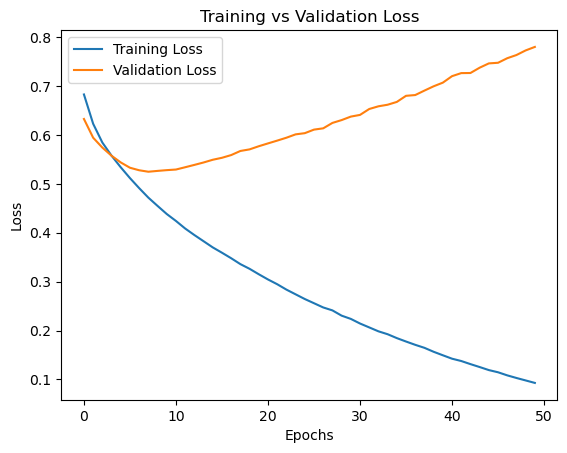

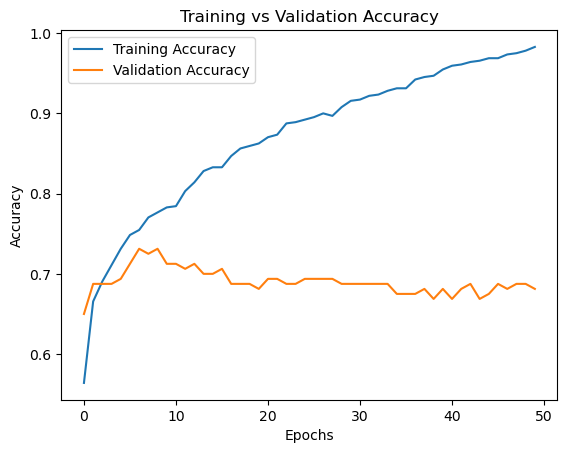

In [7]:
# Plot Training Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Plot Accuracy Curve
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Model Evaluation

After training the model, performance is evaluated using several metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

These metrics help determine how well the model predicts credit risk.

In [8]:
# Make Predictions
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype("int32").flatten()

# Evaluate Model
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step 
Accuracy: 0.735
              precision    recall  f1-score   support

           0       0.55      0.56      0.55        59
           1       0.81      0.81      0.81       141

    accuracy                           0.73       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.74      0.73      0.74       200



### Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the model.

It consists of:

- True Positives
- True Negatives
- False Positives
- False Negatives

This helps analyze the classification performance in detail.

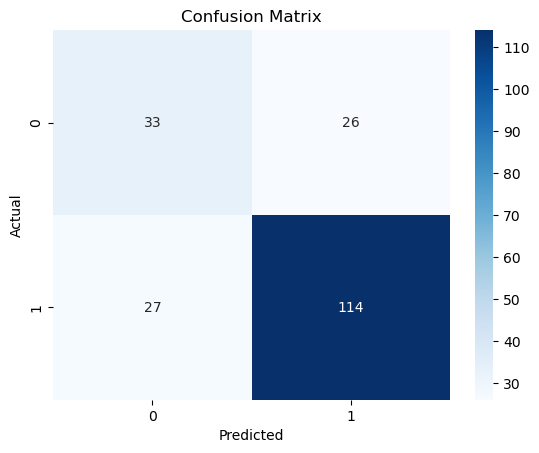

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Conclusion

In this experiment, a Multi-Layer Perceptron (MLP) neural network was implemented to predict credit risk using tabular data.

The dataset was preprocessed using encoding and feature scaling techniques. The neural network was trained using binary cross-entropy loss and the Adam optimizer.

The model achieved a reasonable accuracy and demonstrated how neural networks can be applied to financial risk prediction tasks.

This experiment helped reinforce the concepts of:
- Artificial neurons
- Feedforward neural networks
- Activation functions
- Loss functions
- Model evaluation metrics